In [88]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import seaborn as sns
np.random.seed(123)
n = 25
sample = np.random.exponential(scale=1, size=n)
for i in range(sample.size):
    if(sample[i]>1):
        sample[i]=0
print("Сгенерированная выборка:")
print(sample)

Сгенерированная выборка:
[0.         0.33706748 0.25728408 0.80143368 0.         0.55009754
 0.         0.         0.65572019 0.4977737  0.42034225 0.
 0.57727218 0.0615328  0.50757135 0.         0.20149426 0.19291963
 0.75832884 0.75891865 0.         0.         0.         0.94423638
 0.        ]


In [89]:

median_sample = np.median(sample)
range_sample = np.max(sample) - np.min(sample)
skew_sample = stats.skew(sample)
mode_sample=stats.mode(sample)
print(f"Медиана: {median_sample:.4f}")
print(f"Размах: {range_sample:.4f}")
print(f"Коэффициент асимметрии: {skew_sample:.4f}")
if(mode_sample.count!=1):
    print(f"Мода: {mode_sample.mode:.4f},{mode_sample.count:.4f}")
else:
    print("Моды нет")

Медиана: 0.2015
Размах: 0.9442
Коэффициент асимметрии: 0.5205
Мода: 0.0000,10.0000


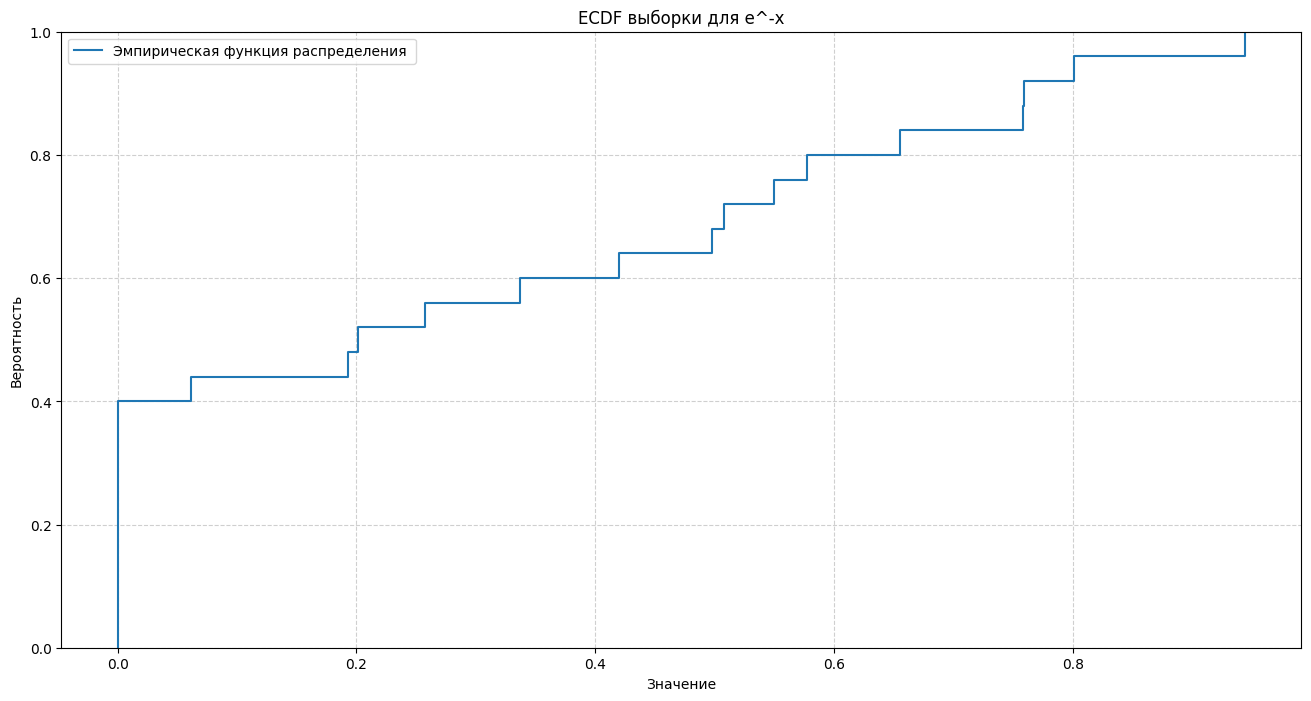

In [90]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.ecdf(sample, label='Эмпирическая функция распределения ')
ax.set_title('ECDF выборки для e^-x')
ax.set_xlabel('Значение')
ax.set_ylabel('Вероятность')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

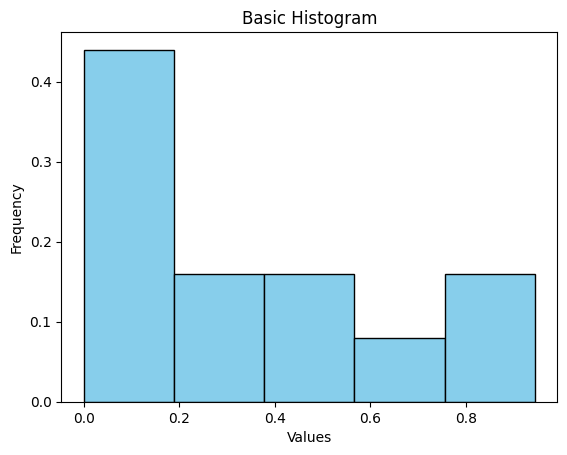

In [91]:
plt.hist(sample, bins=int(1+math.log2(25)),weights=np.ones_like(sample)/len(sample), color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')

plt.show()

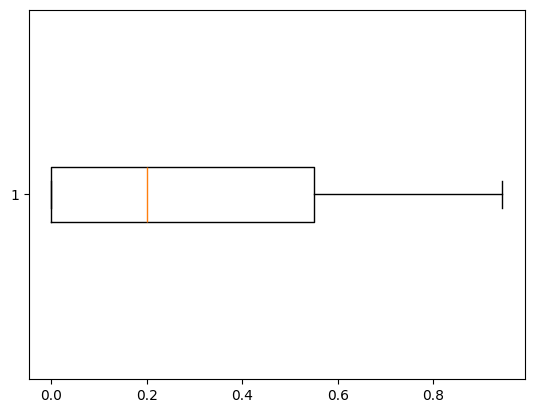

In [92]:

plt.boxplot(sample,vert=False)
plt.show()

Выборочное среднее = 0.301
Стандартная ошибка = 0.064


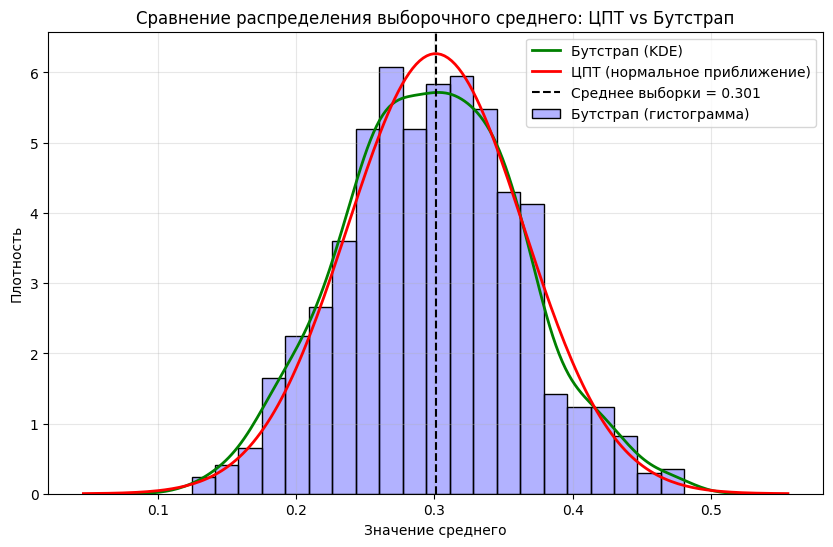

In [93]:
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
std_error = sample_std / np.sqrt(n)

print(f"Выборочное среднее = {sample_mean:.3f}")
print(f"Стандартная ошибка = {std_error:.3f}")

n_bootstrap = 1000
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means[i] = np.mean(boot_sample)

plt.figure(figsize=(10, 6))

sns.histplot(bootstrap_means, stat='density', alpha=0.3, label='Бутстрап (гистограмма)', color='blue')
sns.kdeplot(bootstrap_means, label='Бутстрап (KDE)', color='green', linewidth=2)

x = np.linspace(sample_mean - 4*std_error, sample_mean + 4*std_error, 200)
normal_pdf = stats.norm.pdf(x, loc=sample_mean, scale=std_error)
plt.plot(x, normal_pdf, 'r-', linewidth=2, label='ЦПТ (нормальное приближение)')

plt.axvline(sample_mean, color='black', linestyle='--', label=f'Среднее выборки = {sample_mean:.3f}')

plt.title('Сравнение распределения выборочного среднего: ЦПТ vs Бутстрап')
plt.xlabel('Значение среднего')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[ 2.49991228e-01  3.16078289e-01  4.69001797e-01  5.48207960e-01
  5.94288968e-01  1.04555396e+00  7.22932456e-01  3.77461106e-01
  4.83621965e-01  5.60700690e-01  4.38545435e-01 -1.29359243e-01
  7.75102319e-01  6.37552279e-01  2.31504039e-01  6.73114606e-03
  5.78702539e-01 -1.22562173e-01  4.29281751e-01 -7.39480195e-02
  1.51381480e-01 -9.68569921e-02  4.75671618e-01  1.91853168e-01
  2.36557013e-01  4.27274009e-01  1.04733689e+00  3.66071556e-01
  7.68885669e-01  3.84054440e-01  4.10472519e-01  1.57979628e-01
  1.69778853e-01  3.81177318e-01  6.94759278e-01  5.32103374e-01
  4.51790548e-01  3.85207873e-01  2.66802216e-01  6.22121121e-01
  7.13672726e-01  5.25347778e-01  4.76397515e-01  2.30999965e-01
 -1.27265643e-01  1.88729991e-01  1.09141516e+00  8.03723981e-01
  6.36536817e-01  1.09653332e+00  5.25101515e-01  9.66974397e-01
  7.97527146e-01  3.13964189e-01  4.99457392e-01  1.25955233e+00
  6.16708089e-02  2.79557657e-01  5.69403470e-01  9.30069234e-01
  5.11236048e-01  5.97901

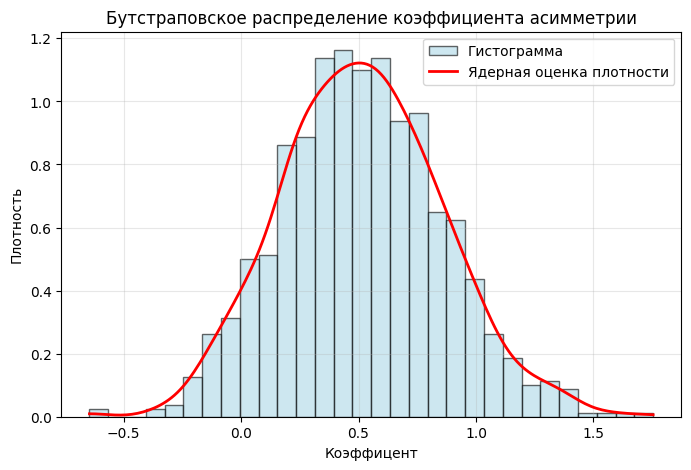

Оценка вероятности P(skewness < 1) = 0.9220


In [94]:


B = 1000
n = len(sample)

boot_skew = np.zeros(B)

for i in range(B):
    sample_sk = np.random.choice(sample, size=n, replace=True)
    boot_skew[i] = stats.skew(sample_sk)

print(boot_skew)
plt.figure(figsize=(8,5))
plt.hist(boot_skew, bins=30, density=True, alpha=0.6, color='lightblue', edgecolor='black', label='Гистограмма')

kde = stats.gaussian_kde(boot_skew)
x_grid = np.linspace(min(boot_skew), max(boot_skew), 200)
plt.plot(x_grid, kde(x_grid), color='red', linewidth=2, label='Ядерная оценка плотности')

plt.title('Бутстраповское распределение коэффициента асимметрии')
plt.xlabel('Коэффицент')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prob_less_1 = np.mean(boot_skew < 1)
print(f"Оценка вероятности P(skewness < 1) = {prob_less_1:.4f}")

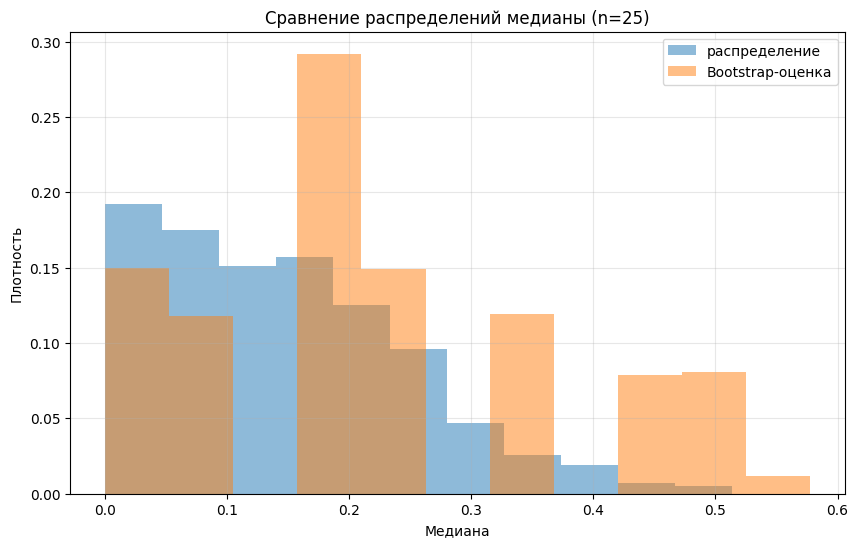

In [95]:

n = 25
B = 1000
R = 1000

true_medians = []
for _ in range(B):
    x = np.random.exponential(scale=1, size=n)
    x[x > 1] = 0
    true_medians.append(np.median(x))
true_medians = np.array(true_medians)

bootstrap_medians = []
for _ in range(R):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_medians.append(np.median(boot_sample))
bootstrap_medians = np.array(bootstrap_medians)


plt.figure(figsize=(10, 6))
plt.hist(true_medians, bins=11, weights=np.ones_like(true_medians)/1000, alpha=0.5, label='распределение')
plt.hist(bootstrap_medians, bins=11, weights=np.ones_like(true_medians)/1000, alpha=0.5, label='Bootstrap-оценка')
plt.xlabel('Медиана')
plt.ylabel('Плотность')
plt.title('Сравнение распределений медианы (n=25)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()